## Data Science C7 Task3
### Name: Obasi Chiamaka Joyce
### Task 3: Pizza Place Sales Analysis

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
#importing the csv files from the zip file, including the dictionary
order_details=pd.read_csv(r"C:\Users\hp\OneDrive\Documents\My Data Science journey\order_details.csv", encoding='latin1')
orders=pd.read_csv(r"C:\Users\hp\OneDrive\Documents\My Data Science journey\orders.csv", encoding='latin1')
pizzas=pd.read_csv(r"C:\Users\hp\OneDrive\Documents\My Data Science journey\pizzas.csv", encoding='latin1')
pizza_types=pd.read_csv(r"C:\Users\hp\OneDrive\Documents\My Data Science journey\pizza_types.csv", encoding='latin1')
data_dictionary=pd.read_csv(r"C:\Users\hp\OneDrive\Documents\My Data Science journey\data_dictionary.csv", encoding='latin1')

In [6]:
#merging all four csv files into one data frame
df= (order_details
     .merge(orders, on='order_id')
     .merge(pizzas, on = 'pizza_id')
     .merge(pizza_types, on = 'pizza_type_id'))

In [7]:
print(df.isna().sum()) #checking for null values

order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64


In [28]:
print(df.dtypes) #checking data types 

order_details_id             int64
order_id                     int64
pizza_id                    object
quantity                     int64
date                datetime64[ns]
time                        object
pizza_type_id               object
size                        object
price                      float64
name                        object
category                    object
ingredients                 object
day                         object
month                       object
hour                         int32
sales                      float64
dtype: object


In [29]:
print(df.duplicated().sum()) #checking for duplicate rows

0


In [31]:
print(len(order_details), len(df)) #to check row count

48620 48620


In [34]:
#checking for foreign keys
missing_orders= order_details[~order_details['order_id'].isin(orders['order_id'])]
print(missing_orders) 

Empty DataFrame
Columns: [order_details_id, order_id, pizza_id, quantity]
Index: []


In [8]:
#converting the date and time
df['date'] = pd.to_datetime(df['date'])
df['day'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

In [9]:
#create a sales column
df['sales'] = df['quantity'] * df['price']

### 1. Total Revenue or Sales

In [10]:
total_revenue=df['sales'].sum()

print(f"Total Revenue: ${total_revenue:}")

Total Revenue: $817860.0499999999


### 2. Total Quantity sold

In [11]:
total_qty= df['quantity'].sum()
print(f"Total Quantity sold: {total_qty}")

Total Quantity sold: 49574


### 3. Total Orders

In [12]:
total_orders = df['order_id'].nunique()
print(f"Total orders: {total_orders:,}")

Total orders: 21,350


### 4. Number of pizza types

In [13]:
num_pizza_types= pizza_types['name'].nunique()
print(f"Number of pizza types: {num_pizza_types}")

Number of pizza types: 32


### 5. Average price

In [14]:
avg_price = pizzas['price'].mean()
print(f"Average pizza price: ${avg_price}")

Average pizza price: $16.440625


### 6. Peak hours of sales

In [15]:
hourly_sales = df.groupby('hour')['sales'].sum().sort_values(ascending=False)
print(hourly_sales)

hour
12    111877.90
13    106065.70
18     89296.85
17     86237.45
19     72628.90
16     70055.40
14     59201.40
20     58215.40
15     52992.30
11     44935.80
21     42029.80
22     22815.15
23      1121.35
10       303.65
9         83.00
Name: sales, dtype: float64


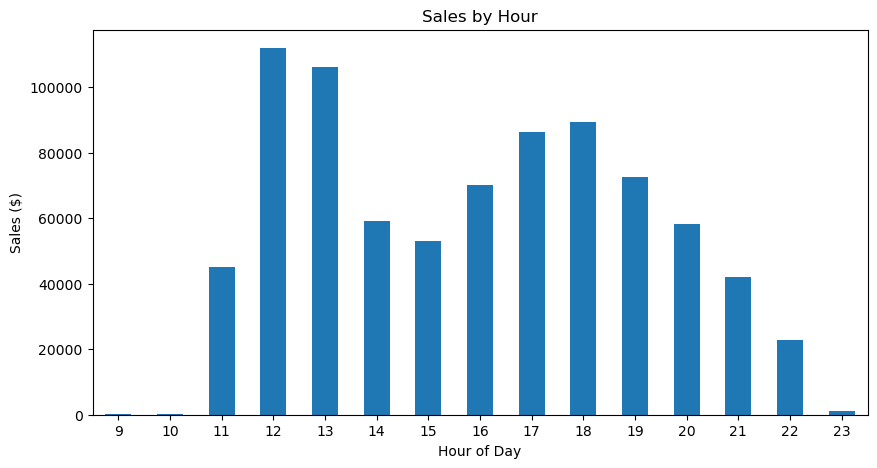

In [16]:
#Bar chart to show the distribution
hourly_sales.sort_index().plot(kind='bar', figsize=(10,5), title='Sales by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.show()

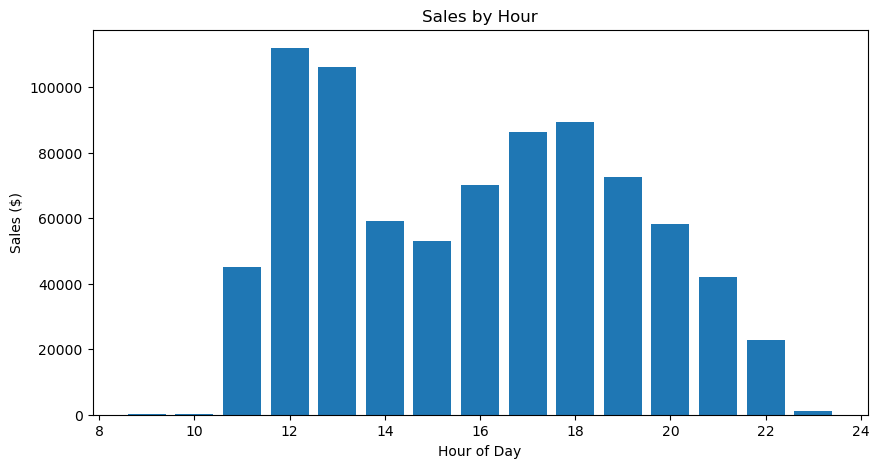

In [17]:
plt.figure(figsize=(10,5))
hourly_sales_sorted= hourly_sales.sort_index()
plt.bar(hourly_sales_sorted.index, hourly_sales_sorted.values)

plt.title('Sales by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.show()

### 7. Sales by each day of the week

In [18]:
#Arrange in weekday order to get sales of each day
days= ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_sales= df.groupby('day')['sales'].sum()

print(daily_sales)

day
Friday       136073.90
Monday       107329.55
Saturday     123182.40
Sunday        99203.50
Thursday     123528.50
Tuesday      114133.80
Wednesday    114408.40
Name: sales, dtype: float64


In [19]:
#day of the week with most sales 
best_day= daily_sales.idxmax()
print(f"Best Sales Day: {best_day}")

Best Sales Day: Friday


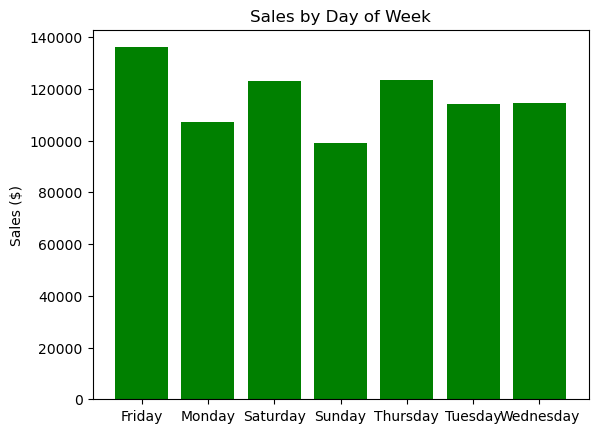

In [20]:
daily_sales_sorted= daily_sales.sort_index()
plt.bar(daily_sales_sorted.index, daily_sales_sorted.values, color= 'green')

plt.title('Sales by Day of Week')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.show()

### 8. Top 5 bestselling pizzas

In [21]:
top5=df.groupby("name")['quantity'].sum().sort_values(ascending=False).head(5)
print(top5)

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64


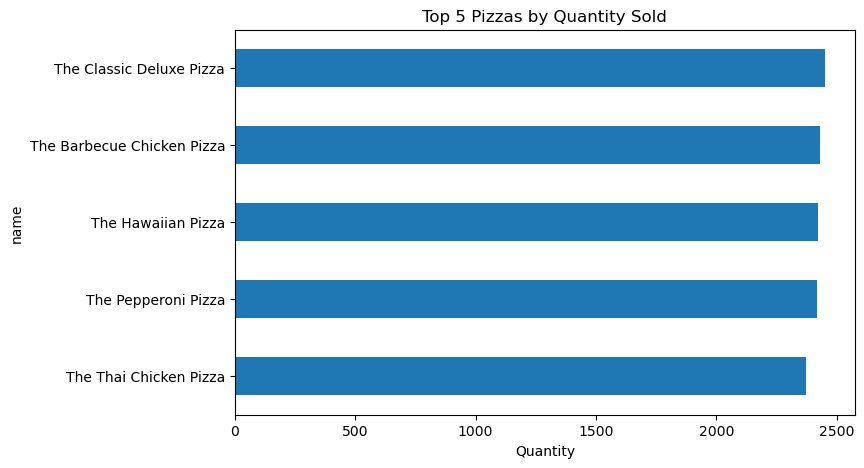

In [22]:
#a horizontal bar chart to display the rank order
top5.plot(kind='barh', figsize=(8,5))
plt.title('Top 5 Pizzas by Quantity Sold')
plt.xlabel('Quantity')
plt.gca().invert_yaxis()
plt.show()

### 9. Sales made in each month

In [23]:
#Arrange in monthly order to get sales of each month
months = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_sales = df.groupby('month')['sales'].sum().reindex(months)
print(monthly_sales)

month
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: sales, dtype: float64


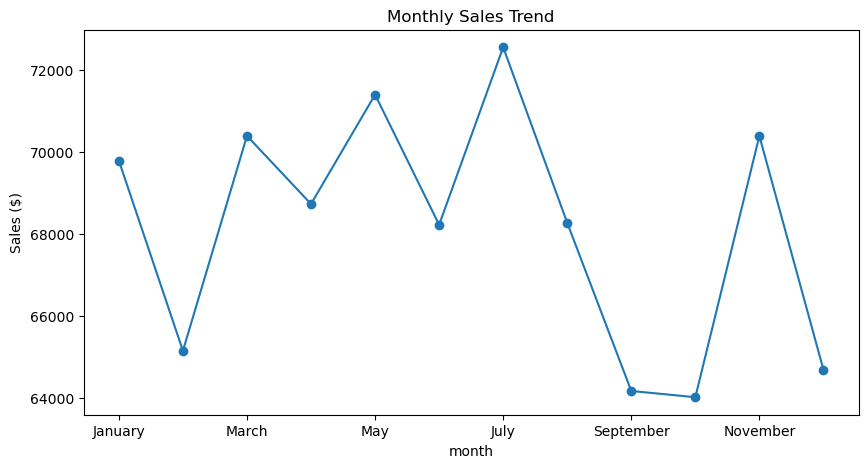

In [24]:
#line plot to show the changes over time
monthly_sales.plot(kind='line', marker='o', figsize=(10,5), title='Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.show()


#### Noticeable Trends
Sales are relatively stable throughout the year, with the highest sales in July and lower sales around September and October. This shows that there's no stong seasonal pattern or trend , it is  astable, steady-demand business.

### 10. Pizza types that are not doing well

In [25]:
#Underperforming pizzas by quantities
Least_by_qty= df.groupby("name")["quantity"].sum().sort_values().head(5)
print(Least_by_qty)

name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64


In [26]:
#Underperforming pizzas by sales
Least_by_sales= df.groupby('name')['sales'].sum().sort_values().head(5)
print(Least_by_sales)

name
The Brie Carre Pizza         11588.50
The Green Garden Pizza       13955.75
The Spinach Supreme Pizza    15277.75
The Mediterranean Pizza      15360.50
The Spinach Pesto Pizza      15596.00
Name: sales, dtype: float64


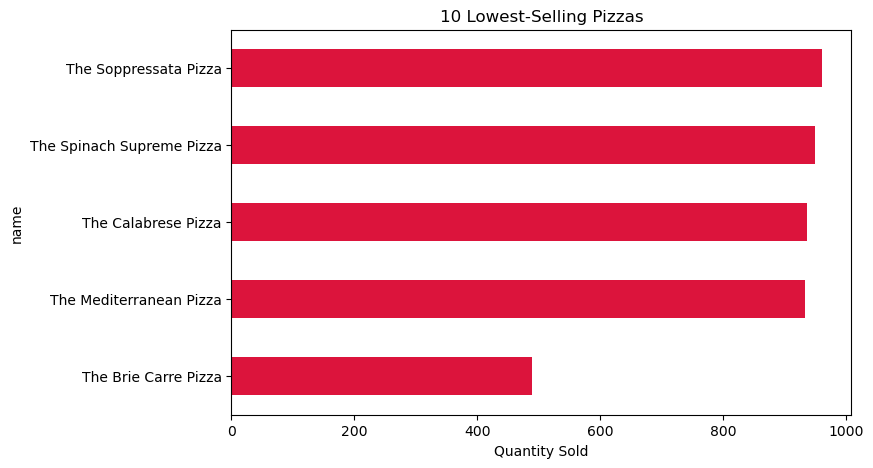

In [27]:
#graph to show the rank order
Least_by_qty.plot(kind='barh', figsize=(8,5), title='10 Lowest-Selling Pizzas', color='crimson')
plt.xlabel('Quantity Sold')
plt.show()

#### Underperforming Pizzas
The weak tail is consistent whether you look by quantity, revenue, or order count:
The Brie Carre Pizza is the clear worst performer — lowest quantity (490), lowest revenue ($11,589).